# **| PROGRAMMING ASSIGNMENT NO.4 |**


 *GUETA, JAMES BRYAN | 2 ECE-C*
#_______________________________________________________________________________

**OBJECTIVES**

1. Filter tabular data using several categorical and numerical conditions;
2. Construct focused DataFrames by selecting relevant features;
3. Summarize the relationship between categorical features and a numerical variable;
4. Communicate a data comparison using clear and correctly labeled plots.

:*This assignment contains three programming problems which covers **Module 4 -
Data Wrangling and Data Visualization**.*

```**Pandas Initiation**``` & ```Matplotlib Initiation```









In [39]:
import pandas as pd
import matplotlib.pyplot as plt

```**Reading and setting up board2.xlsx**```




In [40]:
df = pd.read_excel('board2.xlsx')
displaydf = df[['Math', 'Electronics', 'GEAS', 'Communication']]
means= pd.DataFrame(displaydf.mean(axis=1), columns=['Average'])
df =pd.concat([df, means], axis=1)
df

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
0,S1,Male,Instrumentation,Luzon,58,89,75,78,75.00
1,S2,Female,Communication,Mindanao,52,75,90,52,67.25
2,S3,Female,Instrumentation,Mindanao,83,74,77,57,72.75
3,S4,Male,Instrumentation,Visayas,65,58,91,68,70.50
4,S5,Male,Communication,Luzon,59,86,43,88,69.00
5,S6,Female,Microelectronics,Visayas,88,45,86,83,75.50
6,S7,Female,Instrumentation,Luzon,66,60,60,48,58.50
7,S8,Male,Instrumentation,Luzon,49,81,64,53,61.75
8,S9,Male,Instrumentation,Luzon,50,36,63,42,47.75
9,S10,Male,Microelectronics,Mindanao,80,84,61,44,67.25


# **A. VISAYAS COMMUNICATION DATAFRAME**

Create a DataFrame named *VisComm* containing students whose Hometown is **Visayas** and whose Track is **Communication**. Retain only these columns, in the stated order:

```Name, Gender, Math, Electronics, Average```
---

Display the resulting DataFrame and its number of rows. Both filtering conditions must be applied to
the source dataset before the columns are selected






In [41]:
Viscomm= df.loc [(df['Hometown'] == 'Visayas') & (df['Track'] == 'Communication'), ('Name','Gender','Math','Electronics','Average')]
Viscomm

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


# **VISAYAS FEMALE DATAFRAME**

---

Create a second DataFrame named *VisFemale* containing students whose Hometown is **Visayas** and
whose Gender is **Female**. Retain only:
```Name, Track, GEAS, Electronics, Average```

Display *VisFemale*. Then display only the rows of *VisFemale* whose Average is at least **60**. Do not
overwrite *VisFemale* when performing this second filter.






In [42]:
VisFemale= df.loc [(df['Hometown'] == 'Visayas') & (df['Average'] >= 60), ('Name','Track','GEAS','Electronics','Average')]
VisFemale

,Name,Track,GEAS,Electronics,Average
3,S4,Instrumentation,91,58,70.50
5,S6,Microelectronics,86,45,75.50
11,S12,Communication,84,67,76.00
17,S18,Communication,81,40,63.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75
26,S27,Microelectronics,40,47,60.75
27,S28,Communication,80,53,67.75


# **C. CATEGORY-AVERAGE VISUALIZATION**

---


Examine how the recorded Average differs across the three categorical features Track, Gender, and
Hometown.

a. For each feature, compute the mean of Average for every category using Pandas.

b. Display the three summary tables.

c. Create one figure containing three bar charts: mean Average by Track, by Gender, and by
Hometown.

d. Below the figure, write three concise statements identifying the category with the highest sample
mean for each feature.

**Interpretation rule**: Describe the observed dataset only. A difference in group means does not, by
itself, establish that a feature causes a higher board-exam score.

In [43]:
plt.figure(figsize=(15 , 5 ))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

In [44]:
Track = df.groupby('Track')['Average'].mean().reset_index()
Track

,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500


In [45]:
Gender = df.groupby('Gender')['Average'].mean().reset_index()
Gender

,Gender,Average
0,Female,66.616667
1,Male,67.183333


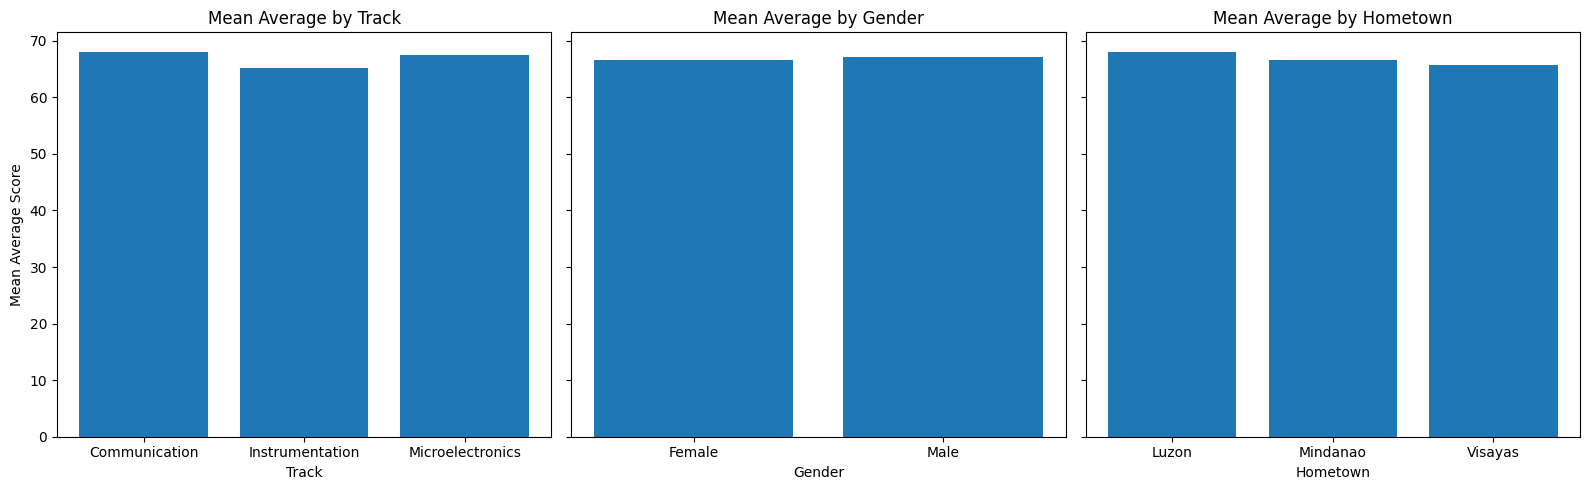

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

axes[0].bar(Track['Track'], Track['Average'])
axes[0].set_title('Mean Average by Track')
axes[0].set_xlabel('Track')
axes[0].set_ylabel('Mean Average Score')

axes[1].bar(Gender['Gender'], Gender['Average'])
axes[1].set_title('Mean Average by Gender')
axes[1].set_xlabel('Gender')

axes[2].bar(Hometown['Hometown'], Hometown['Average'])
axes[2].set_title('Mean Average by Hometown')
axes[2].set_xlabel('Hometown')

plt.tight_layout()
plt.show()

In [70]:
TrackS = Track.loc[Track['Average'].idxmax()]
GenderS = Gender.loc[Gender['Average'].idxmax()]
HometownS = Hometown.loc[Hometown['Average'].idxmax()]

TrackS = f"1. Track: The {TrackS['Track']} track recorded the highest sample mean Average score ({TrackS['Average']:.2f})."
GenderS = f"2. Gender: {GenderS['Gender']} students recorded the highest sample mean Average score ({GenderS['Average']:.2f})."
HometownS = f"3. Hometown: Students from {HometownS['Hometown']} recorded the highest sample mean Average score ({HometownS['Average']:.2f})."

In [77]:
print(TrackS)

1. Track: The Communication track recorded the highest sample mean Average score (67.97).


In [78]:
print(GenderS)

2. Gender: Male students recorded the highest sample mean Average score (67.18).


In [80]:
 print(HometownS)

3. Hometown: Students from Luzon recorded the highest sample mean Average score (68.08).
